In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [10]:
df = pd.read_csv("stockmarket.csv", parse_dates=['Date'])

In [11]:
df

,Date,Open,High,Low,Close,Volume
0,2005-01-03,100.605555,101.204118,100.224376,100.496714,450075
1,2005-01-04,100.325893,104.200992,99.652608,100.358450,474257
2,2005-01-05,101.164953,102.440271,96.512383,101.006138,323167
3,2005-01-06,101.061133,104.413151,102.175506,102.529168,904715
4,2005-01-07,101.654940,107.261288,99.599456,102.295015,722582
...,...,...,...,...,...,...
29995,2119-12-25,89.839838,90.771790,85.787388,90.531012,921396
29996,2119-12-26,91.527623,95.378069,90.156839,91.975616,674801
29997,2119-12-27,91.147500,93.361488,90.174307,91.474249,336068
29998,2119-12-28,90.977802,94.528841,87.553561,89.581892,355024


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    30000 non-null  datetime64[ns]
 1   Open    30000 non-null  float64       
 2   High    30000 non-null  float64       
 3   Low     30000 non-null  float64       
 4   Close   30000 non-null  float64       
 5   Volume  30000 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 1.4 MB


In [13]:
df.count()

Date      30000
Open      30000
High      30000
Low       30000
Close     30000
Volume    30000
dtype: int64

In [14]:
df.describe()

,Date,Open,High,Low,Close,Volume
count,30000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,2062-07-01 12:00:00,128.206122,130.690629,125.682747,128.200810,549256.865400
min,2005-01-03 00:00:00,20.133547,21.299310,16.963232,20.904046,100027.000000
25%,2033-10-02 06:00:00,87.987859,90.345800,85.338902,88.069888,323893.500000
50%,2062-07-01 12:00:00,132.459824,135.085095,129.947384,132.517194,548679.500000
75%,2091-03-30 18:00:00,174.042457,176.654053,171.573029,173.983437,773857.750000
max,2119-12-29 00:00:00,229.149776,232.088627,227.312198,228.371446,999984.000000
std,NaN,50.221859,50.232980,50.227030,50.209351,260022.469783


<Axes: >

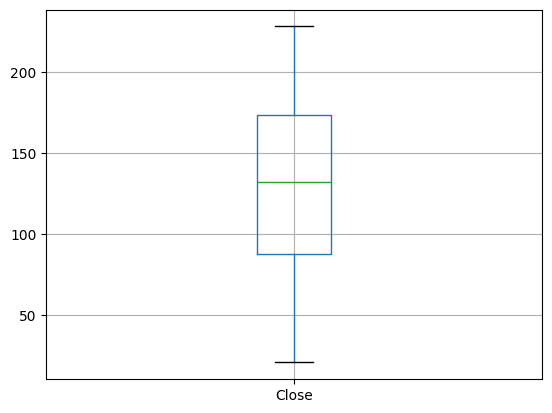

In [16]:
df.boxplot("Close")

In [17]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
29995    False
29996    False
29997    False
29998    False
29999    False
Length: 30000, dtype: bool

array([[<Axes: title={'center': 'Close'}>]], dtype=object)

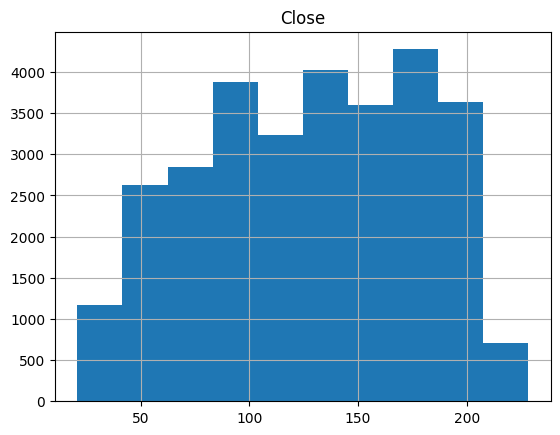

In [18]:
df.hist("Close")

In [ ]:
df.set_index("Date", inplace=True)
df = df[['Close']]

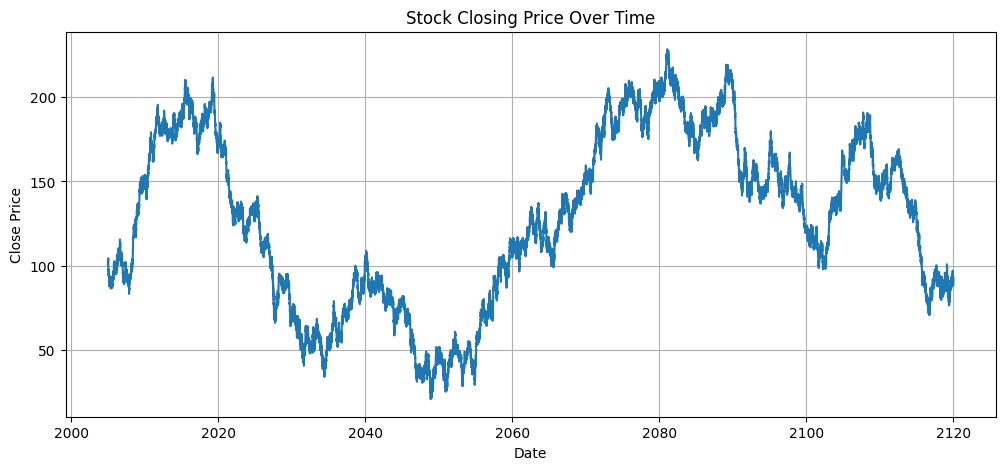

In [3]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'])
plt.title("Stock Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid()
plt.show()

In [7]:
from statsmodels.tsa.arima.model import ARIMA

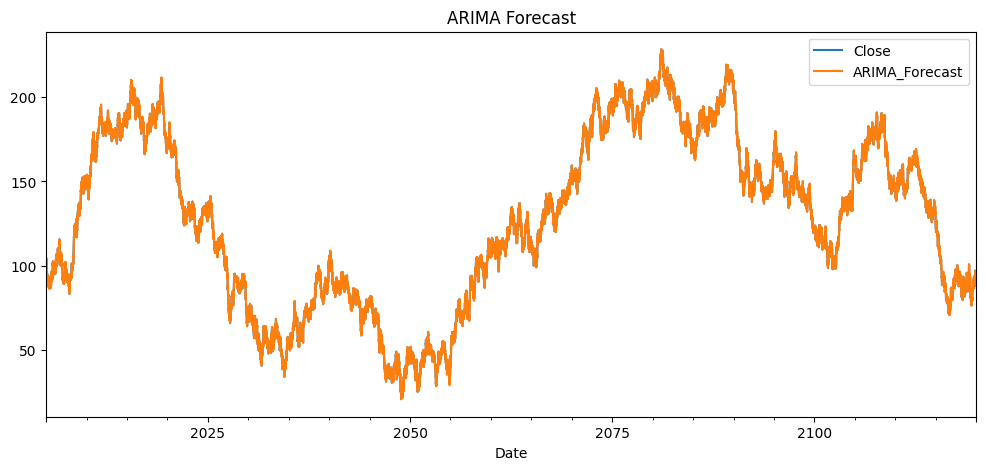

In [4]:
model_arima = ARIMA(df['Close'], order=(5,1,0))
results_arima = model_arima.fit()
df['ARIMA_Forecast'] = results_arima.predict(start=1, end=len(df), typ='levels')
df[['Close', 'ARIMA_Forecast']].plot(figsize=(12,5), title="ARIMA Forecast")
plt.show()

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

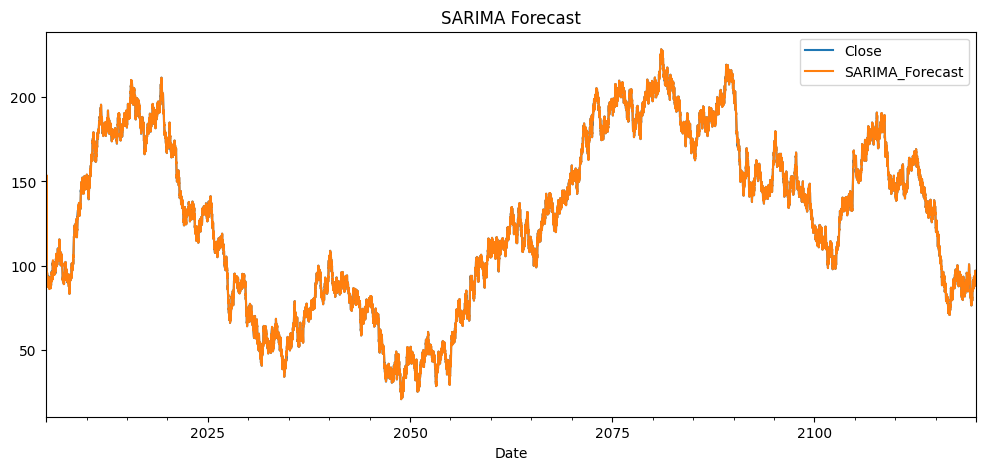

In [5]:

model_sarima = SARIMAX(df['Close'], order=(1,1,1), seasonal_order=(1,1,1,12))
results_sarima = model_sarima.fit()
df['SARIMA_Forecast'] = results_sarima.predict(start=1, end=len(df), dynamic=False)
df[['Close', 'SARIMA_Forecast']].plot(figsize=(12,5), title="SARIMA Forecast")
plt.show()


In [6]:
df.dropna(inplace=True)
print(df.head(), df.shape)


                 Close  ARIMA_Forecast  SARIMA_Forecast
Date                                                   
2005-01-04  100.358450      100.496714       100.496714
2005-01-05  101.006138      100.359209       100.358449
2005-01-06  102.529168      101.003141       101.006138
2005-01-07  102.295015      102.518496       102.529168
2005-01-10  102.060878      102.288526       102.295015 (29999, 3)


In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
data = df.values
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:
x_train, y_train = [], []
for i in range(60, len(scaled_data)):
    x_train.append(scaled_data[i-60:i, 0])
    y_train.append(scaled_data[i, 0])

In [ ]:
x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

In [ ]:

model_lstm = Sequential()
model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model_lstm.add(LSTM(units=50))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.fit(x_train, y_train, epochs=3, batch_size=32)

In [ ]:
predicted_stock_price = model_lstm.predict(x_train)
predicted_stock_price = scaler.inverse_transform(predicted_stock_price)


In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df.index[60:], df['Close'].values[60:], label='True Price')
plt.plot(df.index[60:], predicted_stock_price, label='LSTM Prediction')
plt.legend()
plt.title("LSTM Forecast")
plt.show()
